In [ ]:
# IMPORTANT DATA-PROVENANCE NOTICE (READ BEFORE INTERPRETING RESULTS)
# The pandas-dev/pandas cells in this notebook (roughly the first third) were re-run
# after the accompanying PDF report was finalized. Because the GitHub Actions API
# returns the most recent runs at query time, this re-run pulled a different,
# later snapshot (2,086 cleaned runs) than the snapshots the report's frozen figures
# are based on (Pull A: 2,037 runs: Pull B: 2,007 runs; Pull C: a further refresh -
# see Section 3 and 14.1 of the report). As a result, the pandas-related outputs you
# see below (e.g. random-CV F1 around 0.59, pooled temporal F1 around 0.48) do NOT
# match the report's authoritative pandas figures (random-CV F1 = 0.481 +/- 0.058;
# pooled temporal F1 = 0.198). This is the same live-API data-drift issue documented
# throughout the report - just a further instance of it, occurring after the report
# was frozen.
# The scikit-learn and facebook/react cells later in this notebook DO match the
# report exactly, since they were not re-run afterward.
# For the authoritative, citable pandas figures, refer to the frozen PDF report
# (and its companion Results Log), not to this notebook's current pandas outputs.
# This notebook demonstrates the methodology actually implemented - data collection,
# leakage audit, feature engineering, temporal evaluation, SHAP analysis - not a
# script guaranteed to reproduce identical numbers on a different date.


In [ ]:
import requests
import pandas as pd

owner = "pandas-dev"      
repo = "pandas"         

url = f"https://api.github.com/repos/{owner}/{repo}/actions/runs"
params = {"per_page": 100} 

response = requests.get(url, params=params)
data = response.json()

print("عدد النتايج اللي رجعت:", len(data["workflow_runs"]))

عدد النتايج اللي رجعت: 100


In [ ]:
runs = []
for run in data["workflow_runs"]:
    runs.append({
        "id": run["id"],
        "name": run["name"],                    
        "status": run["status"],                  
        "conclusion": run["conclusion"],         
        "created_at": run["created_at"],           
        "run_started_at": run["run_started_at"],
        "updated_at": run["updated_at"],
        "branch": run["head_branch"],
    })

df = pd.DataFrame(runs)
df.head(10)  

,id,name,status,conclusion,created_at,run_started_at,updated_at,branch
0,32602328596,PR Issue Assignment Gate,completed,success,2026-08-22T22:24:08Z,2026-08-22T22:24:08Z,2026-08-22T22:24:19Z,bug-40587
1,32601955107,Comment Commands,completed,skipped,2026-08-22T22:16:03Z,2026-08-22T22:16:03Z,2026-08-22T22:16:04Z,main
2,32601918360,Unit Tests,completed,failure,2026-08-22T22:15:15Z,2026-08-22T22:15:15Z,2026-08-22T23:01:10Z,fix-masked-array-constructor-values
3,32601918324,Doc Build and Upload,completed,success,2026-08-22T22:15:15Z,2026-08-22T22:15:15Z,2026-08-22T22:27:12Z,fix-masked-array-constructor-values
4,32601918295,Wheel builder,completed,skipped,2026-08-22T22:15:15Z,2026-08-22T22:15:15Z,2026-08-22T22:15:16Z,fix-masked-array-constructor-values
5,32601918266,Package Checks,completed,skipped,2026-08-22T22:15:15Z,2026-08-22T22:15:15Z,2026-08-22T22:15:16Z,fix-masked-array-constructor-values
6,32601918233,GitHub Actions Security Analysis with zizmor 🌈,completed,success,2026-08-22T22:15:15Z,2026-08-22T22:15:15Z,2026-08-22T22:15:42Z,fix-masked-array-constructor-values
7,32601918196,Code Checks,completed,success,2026-08-22T22:15:15Z,2026-08-22T22:15:15Z,2026-08-22T22:45:42Z,fix-masked-array-constructor-values
8,32601762247,Comment Commands,completed,skipped,2026-08-22T22:11:55Z,2026-08-22T22:11:55Z,2026-08-22T22:12:04Z,main
9,32601685938,Unit Tests,completed,failure,2026-08-22T22:10:18Z,2026-08-22T22:10:18Z,2026-08-22T23:20:23Z,main


In [ ]:
df["conclusion"].value_counts()

,count
conclusion,
success,63
skipped,27
failure,9


In [ ]:
df_clean = df[df["conclusion"].isin(["success", "failure"])].copy()
df_clean["conclusion"].value_counts()

,count
conclusion,
success,63
failure,9


In [ ]:
all_runs = []

for page in range(1, 11):   
    params = {"per_page": 100, "page": page}
    response = requests.get(url, params=params)
    page_data = response.json()

    if "workflow_runs" not in page_data or len(page_data["workflow_runs"]) == 0:
        break 

    all_runs.extend(page_data["workflow_runs"])
    print(f"صفحة {page}: جمعنا لحد دلوقتي {len(all_runs)} تشغيلة")

صفحة 1: جمعنا لحد دلوقتي 100 تشغيلة
صفحة 2: جمعنا لحد دلوقتي 200 تشغيلة
صفحة 3: جمعنا لحد دلوقتي 300 تشغيلة
صفحة 4: جمعنا لحد دلوقتي 400 تشغيلة
صفحة 5: جمعنا لحد دلوقتي 500 تشغيلة
صفحة 6: جمعنا لحد دلوقتي 600 تشغيلة
صفحة 7: جمعنا لحد دلوقتي 700 تشغيلة
صفحة 8: جمعنا لحد دلوقتي 800 تشغيلة
صفحة 9: جمعنا لحد دلوقتي 900 تشغيلة
صفحة 10: جمعنا لحد دلوقتي 1000 تشغيلة


In [ ]:
runs = []
for run in all_runs:
    runs.append({
        "id": run["id"],
        "name": run["name"],
        "status": run["status"],
        "conclusion": run["conclusion"],
        "created_at": run["created_at"],
        "run_started_at": run["run_started_at"],
        "updated_at": run["updated_at"],
        "branch": run["head_branch"],
    })

df = pd.DataFrame(runs)
df["conclusion"].value_counts()

,count
conclusion,
success,476
skipped,361
failure,82
cancelled,80


In [ ]:
all_runs = []

for page in range(1, 41):  
    params = {"per_page": 100, "page": page}
    response = requests.get(url, params=params)
    page_data = response.json()

    if "workflow_runs" not in page_data or len(page_data["workflow_runs"]) == 0:
        break

    all_runs.extend(page_data["workflow_runs"])
    if page % 5 == 0:  
        print(f"صفحة {page}: جمعنا لحد دلوقتي {len(all_runs)} تشغيلة")

صفحة 5: جمعنا لحد دلوقتي 500 تشغيلة
صفحة 10: جمعنا لحد دلوقتي 1000 تشغيلة
صفحة 15: جمعنا لحد دلوقتي 1500 تشغيلة
صفحة 20: جمعنا لحد دلوقتي 2000 تشغيلة
صفحة 25: جمعنا لحد دلوقتي 2500 تشغيلة
صفحة 30: جمعنا لحد دلوقتي 3000 تشغيلة
صفحة 35: جمعنا لحد دلوقتي 3500 تشغيلة
صفحة 40: جمعنا لحد دلوقتي 4000 تشغيلة


In [ ]:
runs = []
for run in all_runs:
    runs.append({
        "id": run["id"],
        "name": run["name"],
        "status": run["status"],
        "conclusion": run["conclusion"],
        "created_at": run["created_at"],
        "run_started_at": run["run_started_at"],
        "updated_at": run["updated_at"],
        "branch": run["head_branch"],
    })

df = pd.DataFrame(runs)
df["conclusion"].value_counts()

,count
conclusion,
success,1812
skipped,1528
cancelled,385
failure,274


In [ ]:
df_clean = df[df["conclusion"].isin(["success", "failure"])].copy()

print("إجمالي الصفوف بعد الفلترة:", len(df_clean))
df_clean["conclusion"].value_counts()

إجمالي الصفوف بعد الفلترة: 2086


,count
conclusion,
success,1812
failure,274


In [ ]:
df_clean["created_at"] = pd.to_datetime(df_clean["created_at"])
df_clean["updated_at"] = pd.to_datetime(df_clean["updated_at"])

df_clean["duration_seconds"] = (df_clean["updated_at"] - df_clean["created_at"]).dt.total_seconds()

df_clean["label"] = (df_clean["conclusion"] == "failure").astype(int)

df_clean[["name", "duration_seconds", "conclusion", "label"]].head(10)

,name,duration_seconds,conclusion,label
0,PR Issue Assignment Gate,11.0,success,0
2,Unit Tests,2755.0,failure,1
3,Doc Build and Upload,717.0,success,0
6,GitHub Actions Security Analysis with zizmor 🌈,27.0,success,0
7,Code Checks,1827.0,success,0
9,Unit Tests,4205.0,failure,1
10,Clean closed branch caches,7.0,success,0
11,Package Checks,317.0,success,0
13,Code Checks,1861.0,success,0
15,GitHub Actions Security Analysis with zizmor 🌈,26.0,success,0


In [ ]:
df_clean.groupby("conclusion")["duration_seconds"].describe()

,count,mean,std,min,25%,50%,75%,max
conclusion,,,,,,,,
failure,274.0,2385.302920,1483.366254,5.0,1644.0,2773.5,3061.75,15166.0
success,1812.0,1092.754967,6733.235383,5.0,26.0,633.0,1812.00,276568.0


In [ ]:
df_clean.groupby("name")["label"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
name,,
CodeQL,1.000000,9
Unit Tests,0.504155,361
Code Checks,0.113065,398
Clean closed branch caches,0.085470,117
Wheel builder,0.066667,15
Doc Build and Upload,0.055690,413
PR Issue Assignment Gate,0.007874,127
GitHub Actions Security Analysis with zizmor 🌈,0.006772,443
Comment Commands,0.000000,23


In [ ]:
workflow_counts = df_clean["name"].value_counts()
frequent_workflows = workflow_counts[workflow_counts >= 20].index

df_clean["name_grouped"] = df_clean["name"].apply(
    lambda x: x if x in frequent_workflows else "other"
)

df_clean["name_grouped"].value_counts()

,count
name_grouped,
GitHub Actions Security Analysis with zizmor 🌈,443
Doc Build and Upload,413
Code Checks,398
Unit Tests,361
PR Issue Assignment Gate,127
Clean closed branch caches,117
Package Checks,85
Deprecations Bot,76
other,43


In [ ]:
features = pd.get_dummies(df_clean[["name_grouped", "duration_seconds"]], columns=["name_grouped"])

X = features          
y = df_clean["label"]

print("شكل الـ X:", X.shape)
X.head()

شكل الـ X: (2086, 11)


,duration_seconds,name_grouped_Clean closed branch caches,name_grouped_Code Checks,name_grouped_Comment Commands,name_grouped_Deprecations Bot,name_grouped_Doc Build and Upload,name_grouped_GitHub Actions Security Analysis with zizmor 🌈,name_grouped_PR Issue Assignment Gate,name_grouped_Package Checks,name_grouped_Unit Tests,name_grouped_other
0,11.0,False,False,False,False,False,False,True,False,False,False
2,2755.0,False,False,False,False,False,False,False,False,True,False
3,717.0,False,False,False,False,True,False,False,False,False,False
6,27.0,False,False,False,False,False,True,False,False,False,False
7,1827.0,False,True,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    stratify=y,           
    random_state=42        
)

print("حجم بيانات التدريب:", X_train.shape)
print("حجم بيانات الاختبار:", X_test.shape)
print("\nنسبة الفشل في التدريب:", y_train.mean())
print("نسبة الفشل في الاختبار:", y_test.mean())

حجم بيانات التدريب: (1668, 11)
حجم بيانات الاختبار: (418, 11)

نسبة الفشل في التدريب: 0.13129496402877697
نسبة الفشل في الاختبار: 0.13157894736842105


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",   
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["success", "failure"]))

              precision    recall  f1-score   support

     success       0.94      0.89      0.91       363
     failure       0.46      0.60      0.52        55

    accuracy                           0.85       418
   macro avg       0.70      0.75      0.72       418
weighted avg       0.87      0.85      0.86       418



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[324  39]
 [ 22  33]]


In [ ]:
df_clean["hour_of_day"] = df_clean["created_at"].dt.hour
df_clean["day_of_week"] = df_clean["created_at"].dt.dayofweek   

features = pd.get_dummies(
    df_clean[["name_grouped", "duration_seconds", "hour_of_day", "day_of_week"]],
    columns=["name_grouped"]
)

X = features
y = df_clean["label"]

X.shape

(2086, 13)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model2 = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print(classification_report(y_test, y_pred2, target_names=["success", "failure"]))

              precision    recall  f1-score   support

     success       0.95      0.97      0.96       363
     failure       0.78      0.64      0.70        55

    accuracy                           0.93       418
   macro avg       0.86      0.80      0.83       418
weighted avg       0.92      0.93      0.93       418



In [ ]:
cm2 = confusion_matrix(y_test, y_pred2)
print(cm2)

[[353  10]
 [ 20  35]]


In [ ]:
pip install shap -q
import shap

explainer = shap.TreeExplainer(model2)
shap_values = explainer.shap_values(X_test)

print("شكل الـ shap_values:", shap_values.shape)

شكل الـ shap_values: (418, 13, 2)


/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


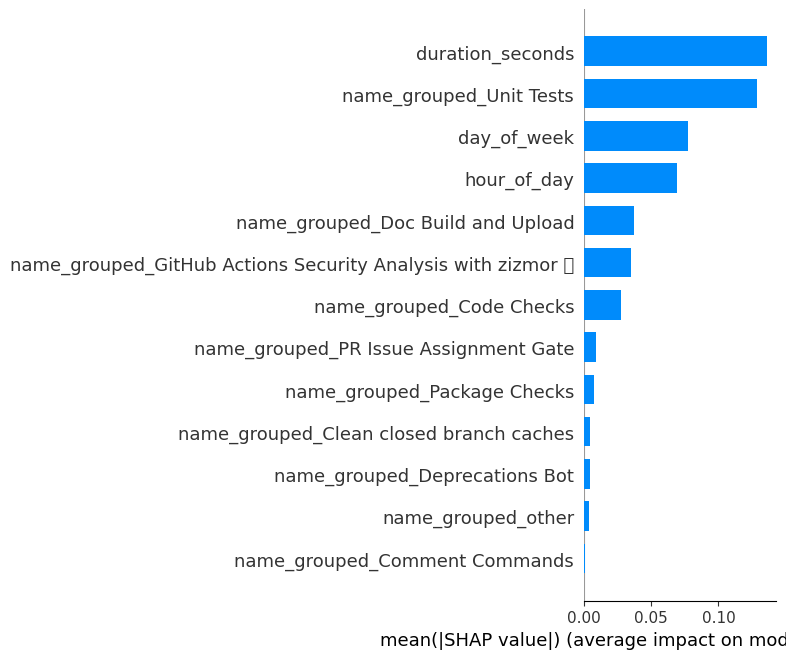

In [ ]:
shap_values_failure = shap_values[:, :, 1]   
shap.summary_plot(shap_values_failure, X_test, plot_type="bar")

/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


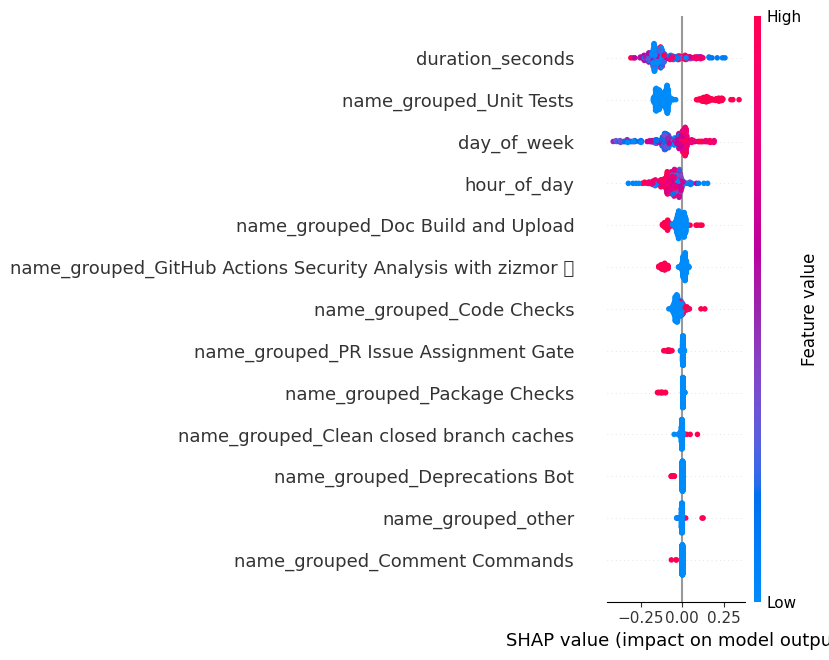

In [ ]:
shap.summary_plot(shap_values_failure, X_test)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

scores = cross_validate(
    model_cv, X, y,
    cv=cv,
    scoring=["precision", "recall", "f1"]
)

print("Precision لكل fold:", scores["test_precision"])
print("Recall لكل fold:   ", scores["test_recall"])
print("F1 لكل fold:        ", scores["test_f1"])

print("\nمتوسط Precision:", scores["test_precision"].mean().round(3), "± ", scores["test_precision"].std().round(3))
print("متوسط Recall:   ", scores["test_recall"].mean().round(3), "± ", scores["test_recall"].std().round(3))
print("متوسط F1:        ", scores["test_f1"].mean().round(3), "± ", scores["test_f1"].std().round(3))

Precision لكل fold: [0.78       0.78723404 0.77777778 0.93103448 0.78378378]
Recall لكل fold:    [0.70909091 0.68518519 0.63636364 0.49090909 0.52727273]
F1 لكل fold:         [0.74285714 0.73267327 0.7        0.64285714 0.63043478]

متوسط Precision: 0.812 ±  0.06
متوسط Recall:    0.61 ±  0.086
متوسط F1:         0.69 ±  0.046


In [ ]:
import matplotlib.pyplot as plt


shap.summary_plot(shap_values_failure, X_test, plot_type="bar", show=False)
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.close()


shap.summary_plot(shap_values_failure, X_test, show=False)
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.close()

print("تم الحفظ")

/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7906/268001256.py:5: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7906/268001256.py:10: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")


تم الحفظ


In [ ]:
from google.colab import files
files.download("shap_summary_bar.png")
files.download("shap_summary_beeswarm.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df_clean.index,
    test_size=0.2,
    stratify=df_clean["label"],
    random_state=42
)

train_df = df_clean.loc[train_idx].copy()
test_df = df_clean.loc[test_idx].copy()

print("Train:", train_df.shape, " Test:", test_df.shape)

Train: (1668, 13)  Test: (418, 13)


In [ ]:
df_clean.to_csv("df_clean.csv", index=False)

In [ ]:
df_clean = pd.read_csv("df_clean.csv")
df_clean["created_at"] = pd.to_datetime(df_clean["created_at"])
df_clean["updated_at"] = pd.to_datetime(df_clean["updated_at"])

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df_clean.index,
    test_size=0.2,
    stratify=df_clean["label"],
    random_state=42
)

train_df = df_clean.loc[train_idx].copy()
test_df = df_clean.loc[test_idx].copy()

print("Train:", train_df.shape, " Test:", test_df.shape)

Train: (1668, 13)  Test: (418, 13)


In [ ]:
workflow_counts_train = train_df["name"].value_counts()
frequent_workflows_train = workflow_counts_train[workflow_counts_train >= 20].index

def group_workflow(name):
    return name if name in frequent_workflows_train else "other"

train_df["name_grouped"] = train_df["name"].apply(group_workflow)
test_df["name_grouped"] = test_df["name"].apply(group_workflow)   

print(train_df["name_grouped"].value_counts())
print("\n--- Test (بنفس الـ mapping) ---")
print(test_df["name_grouped"].value_counts())

name_grouped
GitHub Actions Security Analysis with zizmor 🌈    348
Code Checks                                       339
Doc Build and Upload                              323
Unit Tests                                        276
PR Issue Assignment Gate                          100
Clean closed branch caches                         99
Package Checks                                     71
Deprecations Bot                                   55
other                                              37
Comment Commands                                   20
Name: count, dtype: int64

--- Test (بنفس الـ mapping) ---
name_grouped
GitHub Actions Security Analysis with zizmor 🌈    95
Doc Build and Upload                              90
Unit Tests                                        85
Code Checks                                       59
PR Issue Assignment Gate                          27
Deprecations Bot                                  21
Clean closed branch caches                        18
Pack

In [ ]:
train_df["hour_of_day"] = train_df["created_at"].dt.hour
train_df["day_of_week"] = train_df["created_at"].dt.dayofweek

test_df["hour_of_day"] = test_df["created_at"].dt.hour
test_df["day_of_week"] = test_df["created_at"].dt.dayofweek

print("تم — لاحظ: مفيش duration_seconds خالص في الكود ده")

تم — لاحظ: مفيش duration_seconds خالص في الكود ده


In [ ]:
X_train = pd.get_dummies(train_df[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test = pd.get_dummies(test_df[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df["label"]
y_test = test_df["label"]

print("شكل X_train:", X_train.shape)
print("شكل X_test:", X_test.shape)

شكل X_train: (1668, 12)
شكل X_test: (418, 12)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model_clean = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model_clean.fit(X_train, y_train)
y_pred_clean = model_clean.predict(X_test)

print(classification_report(y_test, y_pred_clean, target_names=["success", "failure"]))

              precision    recall  f1-score   support

     success       0.94      0.90      0.92       363
     failure       0.47      0.62      0.54        55

    accuracy                           0.86       418
   macro avg       0.71      0.76      0.73       418
weighted avg       0.88      0.86      0.87       418



In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

precisions, recalls, f1s = [], [], []

fold_num = 1
for train_i, test_i in cv.split(df_clean, df_clean["label"]):
    fold_train = df_clean.iloc[train_i].copy()
    fold_test = df_clean.iloc[test_i].copy()

    counts = fold_train["name"].value_counts()
    frequent = counts[counts >= 20].index

    fold_train["name_grouped"] = fold_train["name"].apply(lambda x: x if x in frequent else "other")
    fold_test["name_grouped"] = fold_test["name"].apply(lambda x: x if x in frequent else "other")

    fold_train["hour_of_day"] = fold_train["created_at"].dt.hour
    fold_train["day_of_week"] = fold_train["created_at"].dt.dayofweek
    fold_test["hour_of_day"] = fold_test["created_at"].dt.hour
    fold_test["day_of_week"] = fold_test["created_at"].dt.dayofweek

    Xtr = pd.get_dummies(fold_train[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
    Xte = pd.get_dummies(fold_test[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = fold_train["label"]
    yte = fold_test["label"]

    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)

    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(yte, pred)
    r = recall_score(yte, pred)
    f = f1_score(yte, pred)

    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

    print(f"Fold {fold_num}: precision={p:.3f}  recall={r:.3f}  f1={f:.3f}")
    fold_num += 1

print("\nمتوسط Precision:", np.mean(precisions).round(3), "±", np.std(precisions).round(3))
print("متوسط Recall:   ", np.mean(recalls).round(3), "±", np.std(recalls).round(3))
print("متوسط F1:        ", np.mean(f1s).round(3), "±", np.std(f1s).round(3))

Fold 1: precision=0.589  recall=0.782  f1=0.672
Fold 2: precision=0.576  recall=0.704  f1=0.633
Fold 3: precision=0.524  recall=0.600  f1=0.559
Fold 4: precision=0.484  recall=0.564  f1=0.521
Fold 5: precision=0.561  recall=0.582  f1=0.571

متوسط Precision: 0.547 ± 0.038
متوسط Recall:    0.646 ± 0.083
متوسط F1:         0.591 ± 0.054


In [ ]:
df_sorted = df_clean.sort_values("created_at").reset_index(drop=True)

split_point = int(len(df_sorted) * 0.8)

train_df_t = df_sorted.iloc[:split_point].copy()
test_df_t = df_sorted.iloc[split_point:].copy()

print("Train (الأقدم):", train_df_t.shape, " من", train_df_t["created_at"].min(), "لـ", train_df_t["created_at"].max())
print("Test (الأحدث): ", test_df_t.shape, " من", test_df_t["created_at"].min(), "لـ", test_df_t["created_at"].max())
print("\nنسبة الفشل في train:", train_df_t["label"].mean().round(3))
print("نسبة الفشل في test: ", test_df_t["label"].mean().round(3))

Train (الأقدم): (1668, 13)  من 2026-08-13 21:34:28+00:00 لـ 2026-08-21 03:03:56+00:00
Test (الأحدث):  (418, 13)  من 2026-08-21 03:03:56+00:00 لـ 2026-08-22 22:24:08+00:00

نسبة الفشل في train: 0.122
نسبة الفشل في test:  0.17


In [ ]:
counts_t = train_df_t["name"].value_counts()
frequent_t = counts_t[counts_t >= 20].index

train_df_t["name_grouped"] = train_df_t["name"].apply(lambda x: x if x in frequent_t else "other")
test_df_t["name_grouped"] = test_df_t["name"].apply(lambda x: x if x in frequent_t else "other")

train_df_t["hour_of_day"] = train_df_t["created_at"].dt.hour
train_df_t["day_of_week"] = train_df_t["created_at"].dt.dayofweek
test_df_t["hour_of_day"] = test_df_t["created_at"].dt.hour
test_df_t["day_of_week"] = test_df_t["created_at"].dt.dayofweek

X_train_t = pd.get_dummies(train_df_t[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_t = pd.get_dummies(test_df_t[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_t = X_test_t.reindex(columns=X_train_t.columns, fill_value=0)

y_train_t = train_df_t["label"]
y_test_t = test_df_t["label"]

model_time = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_time.fit(X_train_t, y_train_t)
pred_time = model_time.predict(X_test_t)

print(classification_report(y_test_t, pred_time, target_names=["success", "failure"]))
print("\nConfusion matrix:")
print(confusion_matrix(y_test_t, pred_time))

              precision    recall  f1-score   support

     success       0.92      0.94      0.93       347
     failure       0.67      0.62      0.64        71

    accuracy                           0.88       418
   macro avg       0.79      0.78      0.79       418
weighted avg       0.88      0.88      0.88       418


Confusion matrix:
[[325  22]
 [ 27  44]]


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

df_sorted = df_clean.sort_values("created_at").reset_index(drop=True)
n_windows = 5
chunks = np.array_split(df_sorted.index, n_windows)

fold_results = []
all_true = []
all_pred = []

for k in range(1, n_windows):
    train_indices = np.concatenate(chunks[:k])   
    test_indices = chunks[k]                      

    fold_train = df_sorted.loc[train_indices].copy()
    fold_test = df_sorted.loc[test_indices].copy()

    counts = fold_train["name"].value_counts()
    frequent = counts[counts >= 20].index
    fold_train["name_grouped"] = fold_train["name"].apply(lambda x: x if x in frequent else "other")
    fold_test["name_grouped"] = fold_test["name"].apply(lambda x: x if x in frequent else "other")

    fold_train["hour_of_day"] = fold_train["created_at"].dt.hour
    fold_train["day_of_week"] = fold_train["created_at"].dt.dayofweek
    fold_test["hour_of_day"] = fold_test["created_at"].dt.hour
    fold_test["day_of_week"] = fold_test["created_at"].dt.dayofweek

    Xtr = pd.get_dummies(fold_train[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
    Xte = pd.get_dummies(fold_test[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = fold_train["label"]
    yte = fold_test["label"]

    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)

    p = precision_score(yte, pred, zero_division=0)
    r = recall_score(yte, pred, zero_division=0)
    f = f1_score(yte, pred, zero_division=0)

    fold_results.append({
        "window": k,
        "train_size": len(fold_train),
        "test_size": len(fold_test),
        "test_failures": int(yte.sum()),
        "precision": round(p, 3),
        "recall": round(r, 3),
        "f1": round(f, 3),
    })

    all_true.extend(yte.tolist())
    all_pred.extend(pred.tolist())

    print(f"Window {k}: train={len(fold_train)}, test={len(fold_test)}, test_failures={int(yte.sum())}, "
          f"precision={p:.3f}, recall={r:.3f}, f1={f:.3f}")

pooled_precision = precision_score(all_true, all_pred, zero_division=0)
pooled_recall = recall_score(all_true, all_pred, zero_division=0)
pooled_f1 = f1_score(all_true, all_pred, zero_division=0)

print("\n=== النتيجة المجمّعة عبر كل الـ windows ===")
print(f"إجمالي حالات الفشل في كل نوافذ الاختبار: {sum(1 for x in all_true if x == 1)}")
print(f"Pooled Precision: {pooled_precision:.3f}")
print(f"Pooled Recall:    {pooled_recall:.3f}")
print(f"Pooled F1:         {pooled_f1:.3f}")

print("\nConfusion matrix مجمّعة:")
print(confusion_matrix(all_true, all_pred))

Window 1: train=418, test=417, test_failures=87, precision=0.667, recall=0.575, f1=0.617
Window 2: train=835, test=417, test_failures=18, precision=0.056, recall=0.222, f1=0.090
Window 3: train=1252, test=417, test_failures=30, precision=0.346, recall=0.300, f1=0.321
Window 4: train=1669, test=417, test_failures=71, precision=0.667, recall=0.620, f1=0.642

=== النتيجة المجمّعة عبر كل الـ windows ===
إجمالي حالات الفشل في كل نوافذ الاختبار: 206
Pooled Precision: 0.450
Pooled Recall:    0.519
Pooled F1:         0.482

Confusion matrix مجمّعة:
[[1331  131]
 [  99  107]]


In [ ]:
counts_full = df_clean["name"].value_counts()
frequent_full = counts_full[counts_full >= 20].index

df_clean["name_grouped_clean"] = df_clean["name"].apply(lambda x: x if x in frequent_full else "other")
df_clean["hour_of_day"] = df_clean["created_at"].dt.hour
df_clean["day_of_week"] = df_clean["created_at"].dt.dayofweek

X_full = pd.get_dummies(df_clean[["name_grouped_clean", "hour_of_day", "day_of_week"]], columns=["name_grouped_clean"])
y_full = df_clean["label"]

model_final = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_final.fit(X_full, y_full)

print("الموديل النهائي جاهز، مدرب على:", X_full.shape)

الموديل النهائي جاهز، مدرب على: (2086, 12)


In [ ]:
explainer_final = shap.TreeExplainer(model_final)
shap_values_final = explainer_final.shap_values(X_full)

shap_values_final_failure = shap_values_final[:, :, 1]

shap.summary_plot(shap_values_final_failure, X_full, plot_type="bar", show=False)
plt.savefig("shap_bar_leakage_free.png", dpi=150, bbox_inches="tight")
plt.close()

shap.summary_plot(shap_values_final_failure, X_full, show=False)
plt.savefig("shap_beeswarm_leakage_free.png", dpi=150, bbox_inches="tight")
plt.close()

files.download("shap_bar_leakage_free.png")
files.download("shap_beeswarm_leakage_free.png")

print("تم")

/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7906/1283470053.py:7: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_bar_leakage_free.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7906/1283470053.py:11: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_beeswarm_leakage_free.png", dpi=150, bbox_inches="tight")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم


In [ ]:
counts_full = df_clean["name"].value_counts()
frequent_full = counts_full[counts_full >= 20].index

df_clean["name_grouped_clean"] = df_clean["name"].apply(lambda x: x if x in frequent_full else "other")
df_clean["hour_of_day"] = df_clean["created_at"].dt.hour
df_clean["day_of_week"] = df_clean["created_at"].dt.dayofweek

X_full = pd.get_dummies(df_clean[["name_grouped_clean", "hour_of_day", "day_of_week"]], columns=["name_grouped_clean"])
y_full = df_clean["label"]

model_final = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_final.fit(X_full, y_full)

print("الموديل النهائي جاهز، مدرب على:", X_full.shape)

الموديل النهائي جاهز، مدرب على: (2086, 12)


In [ ]:
counts_full = df_clean["name"].value_counts()
frequent_full = counts_full[counts_full >= 20].index

df_clean["name_grouped_clean"] = df_clean["name"].apply(lambda x: x if x in frequent_full else "other")
df_clean["hour_of_day"] = df_clean["created_at"].dt.hour
df_clean["day_of_week"] = df_clean["created_at"].dt.dayofweek

X_full = pd.get_dummies(df_clean[["name_grouped_clean", "hour_of_day", "day_of_week"]], columns=["name_grouped_clean"])
y_full = df_clean["label"]

model_final = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_final.fit(X_full, y_full)

print("الموديل النهائي جاهز، مدرب على:", X_full.shape)

الموديل النهائي جاهز، مدرب على: (2086, 12)


In [ ]:
explainer_final = shap.TreeExplainer(model_final)
shap_values_final = explainer_final.shap_values(X_full)

shap_values_final_failure = shap_values_final[:, :, 1]

shap.summary_plot(shap_values_final_failure, X_full, plot_type="bar", show=False)
plt.savefig("shap_bar_leakage_free.png", dpi=150, bbox_inches="tight")
plt.close()

shap.summary_plot(shap_values_final_failure, X_full, show=False)
plt.savefig("shap_beeswarm_leakage_free.png", dpi=150, bbox_inches="tight")
plt.close()

files.download("shap_bar_leakage_free.png")
files.download("shap_beeswarm_leakage_free.png")

print("تم")

/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7906/1283470053.py:7: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_bar_leakage_free.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7906/1283470053.py:11: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_beeswarm_leakage_free.png", dpi=150, bbox_inches="tight")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم


In [ ]:
train_df_t = train_df_t.sort_values("created_at").reset_index(drop=True).copy()
test_df_t = test_df_t.sort_values("created_at").reset_index(drop=True).copy()

grp = train_df_t.groupby("name_grouped")["label"]

train_df_t["cum_failures_incl_current"] = grp.cumsum()
train_df_t["previous_failures"] = (
    train_df_t.groupby("name_grouped")["cum_failures_incl_current"].shift(1)
)

train_df_t["previous_runs"] = train_df_t.groupby("name_grouped").cumcount()

train_df_t["historical_failure_rate"] = (
    train_df_t["previous_failures"] / train_df_t["previous_runs"]
)

default_rate = train_df_t["label"].mean()
train_df_t["historical_failure_rate"] = train_df_t["historical_failure_rate"].fillna(default_rate)

print(train_df_t[["created_at", "name_grouped", "previous_runs", "previous_failures", "historical_failure_rate"]].head(15))

                  created_at                                    name_grouped  \
0  2026-08-13 21:34:28+00:00                                      Unit Tests   
1  2026-08-13 21:35:07+00:00                            Doc Build and Upload   
2  2026-08-13 21:35:07+00:00  GitHub Actions Security Analysis with zizmor 🌈   
3  2026-08-13 21:49:30+00:00                                      Unit Tests   
4  2026-08-13 21:49:30+00:00  GitHub Actions Security Analysis with zizmor 🌈   
5  2026-08-13 21:49:30+00:00                                     Code Checks   
6  2026-08-13 21:49:30+00:00                            Doc Build and Upload   
7  2026-08-13 22:04:41+00:00                                     Code Checks   
8  2026-08-13 22:04:41+00:00                                      Unit Tests   
9  2026-08-13 22:04:41+00:00                            Doc Build and Upload   
10 2026-08-13 22:04:41+00:00  GitHub Actions Security Analysis with zizmor 🌈   
11 2026-08-13 22:08:31+00:00            

In [ ]:
historical_rates = train_df_t.groupby("name_grouped")["label"].mean()
test_df_t["historical_failure_rate"] = test_df_t["name_grouped"].map(historical_rates).fillna(default_rate)

X_train_base = pd.get_dummies(train_df_t[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_base = pd.get_dummies(test_df_t[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_base = X_test_base.reindex(columns=X_train_base.columns, fill_value=0)

model_base = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_base.fit(X_train_base, y_train_t)
pred_base = model_base.predict(X_test_base)

print("=== Model A: Baseline ===")
print(classification_report(y_test_t, pred_base, target_names=["success", "failure"]))

X_train_hist = pd.get_dummies(train_df_t[["name_grouped", "hour_of_day", "day_of_week", "historical_failure_rate"]], columns=["name_grouped"])
X_test_hist = pd.get_dummies(test_df_t[["name_grouped", "hour_of_day", "day_of_week", "historical_failure_rate"]], columns=["name_grouped"])
X_test_hist = X_test_hist.reindex(columns=X_train_hist.columns, fill_value=0)

model_hist = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_hist.fit(X_train_hist, y_train_t)
pred_hist = model_hist.predict(X_test_hist)

print("\n=== Model B: Baseline + Historical Failure Rate ===")
print(classification_report(y_test_t, pred_hist, target_names=["success", "failure"]))

=== Model A: Baseline ===
              precision    recall  f1-score   support

     success       0.87      0.82      0.84       347
     failure       0.30      0.39      0.34        71

    accuracy                           0.74       418
   macro avg       0.59      0.60      0.59       418
weighted avg       0.77      0.74      0.76       418


=== Model B: Baseline + Historical Failure Rate ===
              precision    recall  f1-score   support

     success       0.85      0.97      0.91       347
     failure       0.54      0.20      0.29        71

    accuracy                           0.83       418
   macro avg       0.70      0.58      0.60       418
weighted avg       0.80      0.83      0.80       418



In [ ]:
fold_results_hist = []
all_true_hist = []
all_pred_hist = []

In [ ]:
for k in range(1, n_windows):
    train_indices = np.concatenate(chunks[:k])
    test_indices = chunks[k]
    fold_train = df_sorted.loc[train_indices].sort_values("created_at").reset_index(drop=True).copy()
    fold_test = df_sorted.loc[test_indices].copy()
    counts = fold_train["name"].value_counts()
    frequent = counts[counts >= 20].index
    fold_train["name_grouped"] = fold_train["name"].apply(lambda x: x if x in frequent else "other")
    fold_test["name_grouped"] = fold_test["name"].apply(lambda x: x if x in frequent else "other")
    fold_train["hour_of_day"] = fold_train["created_at"].dt.hour
    fold_train["day_of_week"] = fold_train["created_at"].dt.dayofweek
    fold_test["hour_of_day"] = fold_test["created_at"].dt.hour
    fold_test["day_of_week"] = fold_test["created_at"].dt.dayofweek
    grouped_labels = fold_train.groupby("name_grouped")["label"]
    fold_train["cum_incl"] = grouped_labels.cumsum()
    grouped_cum = fold_train.groupby("name_grouped")["cum_incl"]
    fold_train["prev_failures"] = grouped_cum.shift(1)
    fold_train["prev_runs"] = fold_train.groupby("name_grouped").cumcount()
    default_rate_fold = fold_train["label"].mean()
    raw_rate = fold_train["prev_failures"] / fold_train["prev_runs"]
    fold_train["historical_failure_rate"] = raw_rate.fillna(default_rate_fold)
    hist_rates_fold = fold_train.groupby("name_grouped")["label"].mean()
    mapped_rate = fold_test["name_grouped"].map(hist_rates_fold)
    fold_test["historical_failure_rate"] = mapped_rate.fillna(default_rate_fold)
    cols = ["name_grouped", "hour_of_day", "day_of_week", "historical_failure_rate"]
    Xtr = pd.get_dummies(fold_train[cols], columns=["name_grouped"])
    Xte = pd.get_dummies(fold_test[cols], columns=["name_grouped"])
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)
    ytr = fold_train["label"]
    yte = fold_test["label"]
    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    p = precision_score(yte, pred, zero_division=0)
    r = recall_score(yte, pred, zero_division=0)
    f = f1_score(yte, pred, zero_division=0)
    result_row = {"window": k, "test_failures": int(yte.sum()), "precision": round(p, 3), "recall": round(r, 3), "f1": round(f, 3)}
    fold_results_hist.append(result_row)
    all_true_hist.extend(yte.tolist())
    all_pred_hist.extend(pred.tolist())
    print("Window", k, "f1=", round(f, 3))

Window 1 f1= 0.634
Window 2 f1= 0.133
Window 3 f1= 0.125
Window 4 f1= 0.585


In [ ]:
pooled_p = precision_score(all_true_hist, all_pred_hist, zero_division=0)
pooled_r = recall_score(all_true_hist, all_pred_hist, zero_division=0)
pooled_f = f1_score(all_true_hist, all_pred_hist, zero_division=0)
print("Pooled Precision:", round(pooled_p, 3))
print("Pooled Recall:", round(pooled_r, 3))
print("Pooled F1:", round(pooled_f, 3))

Pooled Precision: 0.5
Pooled Recall: 0.461
Pooled F1: 0.48


In [ ]:
owner_sk = "scikit-learn"
repo_sk = "scikit-learn"
url_sk = f"https://api.github.com/repos/{owner_sk}/{repo_sk}/actions/runs"

all_runs_sk = []
for page in range(1, 41):
    params = {"per_page": 100, "page": page}
    response = requests.get(url_sk, params=params)
    page_data = response.json()
    if "workflow_runs" not in page_data or len(page_data["workflow_runs"]) == 0:
        break
    all_runs_sk.extend(page_data["workflow_runs"])

print("إجمالي تشغيلات scikit-learn:", len(all_runs_sk))

إجمالي تشغيلات scikit-learn: 1700


In [ ]:
runs_sk = []
for run in all_runs_sk:
    runs_sk.append({
        "id": run["id"],
        "name": run["name"],
        "status": run["status"],
        "conclusion": run["conclusion"],
        "created_at": run["created_at"],
        "updated_at": run["updated_at"],
    })

df_sk = pd.DataFrame(runs_sk)
df_clean_sk = df_sk[df_sk["conclusion"].isin(["success", "failure"])].copy()
df_clean_sk["created_at"] = pd.to_datetime(df_clean_sk["created_at"])
df_clean_sk["updated_at"] = pd.to_datetime(df_clean_sk["updated_at"])
df_clean_sk["label"] = (df_clean_sk["conclusion"] == "failure").astype(int)

print("shape:", df_clean_sk.shape)
print(df_clean_sk["conclusion"].value_counts())
print("نطاق التاريخ:", df_clean_sk["created_at"].min(), "->", df_clean_sk["created_at"].max())

shape: (857, 7)
conclusion
success    832
failure     25
Name: count, dtype: int64
نطاق التاريخ: 2026-08-19 08:38:06+00:00 -> 2026-08-22 16:16:08+00:00


In [ ]:
df_sorted_sk = df_clean_sk.sort_values("created_at").reset_index(drop=True)
split_point_sk = int(len(df_sorted_sk) * 0.8)

train_sk = df_sorted_sk.iloc[:split_point_sk].copy()
test_sk = df_sorted_sk.iloc[split_point_sk:].copy()

counts_sk = train_sk["name"].value_counts()
frequent_sk = counts_sk[counts_sk >= 20].index
train_sk["name_grouped"] = train_sk["name"].apply(lambda x: x if x in frequent_sk else "other")
test_sk["name_grouped"] = test_sk["name"].apply(lambda x: x if x in frequent_sk else "other")

train_sk["hour_of_day"] = train_sk["created_at"].dt.hour
train_sk["day_of_week"] = train_sk["created_at"].dt.dayofweek
test_sk["hour_of_day"] = test_sk["created_at"].dt.hour
test_sk["day_of_week"] = test_sk["created_at"].dt.dayofweek

print("Train:", train_sk.shape, " Test:", test_sk.shape)
print("فشل في train:", train_sk["label"].sum(), " فشل في test:", test_sk["label"].sum())

Train: (685, 10)  Test: (172, 10)
فشل في train: 18  فشل في test: 7


In [ ]:
X_train_sk = pd.get_dummies(train_sk[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_sk = pd.get_dummies(test_sk[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_sk = X_test_sk.reindex(columns=X_train_sk.columns, fill_value=0)

y_train_sk = train_sk["label"]
y_test_sk = test_sk["label"]

model_sk = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_sk.fit(X_train_sk, y_train_sk)
pred_sk = model_sk.predict(X_test_sk)

print(classification_report(y_test_sk, pred_sk, target_names=["success", "failure"]))
print("Confusion matrix:")
print(confusion_matrix(y_test_sk, pred_sk))

              precision    recall  f1-score   support

     success       0.98      0.92      0.95       165
     failure       0.24      0.57      0.33         7

    accuracy                           0.91       172
   macro avg       0.61      0.75      0.64       172
weighted avg       0.95      0.91      0.92       172

Confusion matrix:
[[152  13]
 [  3   4]]


In [ ]:
owner_ex = "expressjs"
repo_ex = "express"
url_ex = f"https://api.github.com/repos/{owner_ex}/{repo_ex}/actions/runs"

all_runs_ex = []
for page in range(1, 41):
    params = {"per_page": 100, "page": page}
    response = requests.get(url_ex, params=params)
    page_data = response.json()
    if "workflow_runs" not in page_data or len(page_data["workflow_runs"]) == 0:
        break
    all_runs_ex.extend(page_data["workflow_runs"])

print("إجمالي تشغيلات express:", len(all_runs_ex))

إجمالي تشغيلات express: 100


In [ ]:
runs_ex = []
for run in all_runs_ex:
    runs_ex.append({
        "id": run["id"],
        "name": run["name"],
        "status": run["status"],
        "conclusion": run["conclusion"],
        "created_at": run["created_at"],
        "updated_at": run["updated_at"],
    })

df_ex = pd.DataFrame(runs_ex)
df_clean_ex = df_ex[df_ex["conclusion"].isin(["success", "failure"])].copy()
df_clean_ex["created_at"] = pd.to_datetime(df_clean_ex["created_at"])
df_clean_ex["updated_at"] = pd.to_datetime(df_clean_ex["updated_at"])
df_clean_ex["label"] = (df_clean_ex["conclusion"] == "failure").astype(int)

print("shape:", df_clean_ex.shape)
print(df_clean_ex["conclusion"].value_counts())
print("نطاق التاريخ:", df_clean_ex["created_at"].min(), "->", df_clean_ex["created_at"].max())

shape: (77, 7)
conclusion
success    73
failure     4
Name: count, dtype: int64
نطاق التاريخ: 2026-07-13 03:54:46+00:00 -> 2026-08-22 20:59:57+00:00


In [ ]:
owner_re = "facebook"
repo_re = "react"
url_re = f"https://api.github.com/repos/{owner_re}/{repo_re}/actions/runs"

all_runs_re = []
for page in range(1, 41):
    params = {"per_page": 100, "page": page}
    response = requests.get(url_re, params=params)
    page_data = response.json()
    if "workflow_runs" not in page_data or len(page_data["workflow_runs"]) == 0:
        break
    all_runs_re.extend(page_data["workflow_runs"])

print("إجمالي تشغيلات react:", len(all_runs_re))

إجمالي تشغيلات react: 1700


In [ ]:
runs_re = []
for run in all_runs_re:
    runs_re.append({
        "id": run["id"],
        "name": run["name"],
        "status": run["status"],
        "conclusion": run["conclusion"],
        "created_at": run["created_at"],
        "updated_at": run["updated_at"],
    })

df_re = pd.DataFrame(runs_re)
df_clean_re = df_re[df_re["conclusion"].isin(["success", "failure"])].copy()
df_clean_re["created_at"] = pd.to_datetime(df_clean_re["created_at"])
df_clean_re["updated_at"] = pd.to_datetime(df_clean_re["updated_at"])
df_clean_re["label"] = (df_clean_re["conclusion"] == "failure").astype(int)

print("shape:", df_clean_re.shape)
print(df_clean_re["conclusion"].value_counts())
print("نطاق التاريخ:", df_clean_re["created_at"].min(), "->", df_clean_re["created_at"].max())

shape: (1354, 7)
conclusion
success    1295
failure      59
Name: count, dtype: int64
نطاق التاريخ: 2026-08-09 19:15:11+00:00 -> 2026-08-22 23:05:47+00:00


In [ ]:
df_sorted_re = df_clean_re.sort_values("created_at").reset_index(drop=True)
split_point_re = int(len(df_sorted_re) * 0.8)

train_re = df_sorted_re.iloc[:split_point_re].copy()
test_re = df_sorted_re.iloc[split_point_re:].copy()

counts_re = train_re["name"].value_counts()
frequent_re = counts_re[counts_re >= 20].index
train_re["name_grouped"] = train_re["name"].apply(lambda x: x if x in frequent_re else "other")
test_re["name_grouped"] = test_re["name"].apply(lambda x: x if x in frequent_re else "other")

train_re["hour_of_day"] = train_re["created_at"].dt.hour
train_re["day_of_week"] = train_re["created_at"].dt.dayofweek
test_re["hour_of_day"] = test_re["created_at"].dt.hour
test_re["day_of_week"] = test_re["created_at"].dt.dayofweek

print("Train:", train_re.shape, " Test:", test_re.shape)
print("فشل في train:", train_re["label"].sum(), " فشل في test:", test_re["label"].sum())

Train: (1083, 10)  Test: (271, 10)
فشل في train: 33  فشل في test: 26


In [ ]:
X_train_re = pd.get_dummies(train_re[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_re = pd.get_dummies(test_re[["name_grouped", "hour_of_day", "day_of_week"]], columns=["name_grouped"])
X_test_re = X_test_re.reindex(columns=X_train_re.columns, fill_value=0)

y_train_re = train_re["label"]
y_test_re = test_re["label"]

model_re = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_re.fit(X_train_re, y_train_re)
pred_re = model_re.predict(X_test_re)

print(classification_report(y_test_re, pred_re, target_names=["success", "failure"]))
print("Confusion matrix:")
print(confusion_matrix(y_test_re, pred_re))

              precision    recall  f1-score   support

     success       0.91      1.00      0.95       245
     failure       1.00      0.08      0.14        26

    accuracy                           0.91       271
   macro avg       0.96      0.54      0.55       271
weighted avg       0.92      0.91      0.88       271

Confusion matrix:
[[245   0]
 [ 24   2]]


In [ ]:
n_windows_re = 5
chunks_re = np.array_split(df_sorted_re.index, n_windows_re)

fold_results_re = []
all_true_re = []
all_pred_re = []

for k in range(1, n_windows_re):
    train_indices = np.concatenate(chunks_re[:k])
    test_indices = chunks_re[k]

    fold_train = df_sorted_re.loc[train_indices].copy()
    fold_test = df_sorted_re.loc[test_indices].copy()

    counts = fold_train["name"].value_counts()
    frequent = counts[counts >= 20].index
    fold_train["name_grouped"] = fold_train["name"].apply(lambda x: x if x in frequent else "other")
    fold_test["name_grouped"] = fold_test["name"].apply(lambda x: x if x in frequent else "other")

    fold_train["hour_of_day"] = fold_train["created_at"].dt.hour
    fold_train["day_of_week"] = fold_train["created_at"].dt.dayofweek
    fold_test["hour_of_day"] = fold_test["created_at"].dt.hour
    fold_test["day_of_week"] = fold_test["created_at"].dt.dayofweek

    cols = ["name_grouped", "hour_of_day", "day_of_week"]
    Xtr = pd.get_dummies(fold_train[cols], columns=["name_grouped"])
    Xte = pd.get_dummies(fold_test[cols], columns=["name_grouped"])
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = fold_train["label"]
    yte = fold_test["label"]

    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)

    p = precision_score(yte, pred, zero_division=0)
    r = recall_score(yte, pred, zero_division=0)
    f = f1_score(yte, pred, zero_division=0)

    fold_results_re.append({"window": k, "test_failures": int(yte.sum()), "f1": round(f, 3)})
    all_true_re.extend(yte.tolist())
    all_pred_re.extend(pred.tolist())

    print("Window", k, "test_failures=", int(yte.sum()), "f1=", round(f, 3))

pooled_p_re = precision_score(all_true_re, all_pred_re, zero_division=0)
pooled_r_re = recall_score(all_true_re, all_pred_re, zero_division=0)
pooled_f_re = f1_score(all_true_re, all_pred_re, zero_division=0)
print("\nPooled Precision:", round(pooled_p_re, 3))
print("Pooled Recall:", round(pooled_r_re, 3))
print("Pooled F1:", round(pooled_f_re, 3))

Window 1 test_failures= 4 f1= 0.095
Window 2 test_failures= 6 f1= 0.5
Window 3 test_failures= 10 f1= 0.5
Window 4 test_failures= 26 f1= 0.143

Pooled Precision: 0.323
Pooled Recall: 0.217
Pooled F1: 0.26


In [ ]:
cv_sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

precisions_sk, recalls_sk, f1s_sk = [], [], []

for train_i, test_i in cv_sk.split(df_clean_sk, df_clean_sk["label"]):
    fold_train = df_clean_sk.iloc[train_i].copy()
    fold_test = df_clean_sk.iloc[test_i].copy()

    counts = fold_train["name"].value_counts()
    frequent = counts[counts >= 20].index
    fold_train["name_grouped"] = fold_train["name"].apply(lambda x: x if x in frequent else "other")
    fold_test["name_grouped"] = fold_test["name"].apply(lambda x: x if x in frequent else "other")

    fold_train["hour_of_day"] = fold_train["created_at"].dt.hour
    fold_train["day_of_week"] = fold_train["created_at"].dt.dayofweek
    fold_test["hour_of_day"] = fold_test["created_at"].dt.hour
    fold_test["day_of_week"] = fold_test["created_at"].dt.dayofweek

    cols = ["name_grouped", "hour_of_day", "day_of_week"]
    Xtr = pd.get_dummies(fold_train[cols], columns=["name_grouped"])
    Xte = pd.get_dummies(fold_test[cols], columns=["name_grouped"])
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = fold_train["label"]
    yte = fold_test["label"]

    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)

    precisions_sk.append(precision_score(yte, pred, zero_division=0))
    recalls_sk.append(recall_score(yte, pred, zero_division=0))
    f1s_sk.append(f1_score(yte, pred, zero_division=0))

print("scikit-learn Random CV:")
print("Precision:", round(np.mean(precisions_sk), 3), "±", round(np.std(precisions_sk), 3))
print("Recall:", round(np.mean(recalls_sk), 3), "±", round(np.std(recalls_sk), 3))
print("F1:", round(np.mean(f1s_sk), 3), "±", round(np.std(f1s_sk), 3))

scikit-learn Random CV:
Precision: 0.483 ± 0.255
Recall: 0.6 ± 0.219
F1: 0.516 ± 0.218


In [ ]:
cv_re = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

precisions_re2, recalls_re2, f1s_re2 = [], [], []

for train_i, test_i in cv_re.split(df_clean_re, df_clean_re["label"]):
    fold_train = df_clean_re.iloc[train_i].copy()
    fold_test = df_clean_re.iloc[test_i].copy()

    counts = fold_train["name"].value_counts()
    frequent = counts[counts >= 20].index
    fold_train["name_grouped"] = fold_train["name"].apply(lambda x: x if x in frequent else "other")
    fold_test["name_grouped"] = fold_test["name"].apply(lambda x: x if x in frequent else "other")

    fold_train["hour_of_day"] = fold_train["created_at"].dt.hour
    fold_train["day_of_week"] = fold_train["created_at"].dt.dayofweek
    fold_test["hour_of_day"] = fold_test["created_at"].dt.hour
    fold_test["day_of_week"] = fold_test["created_at"].dt.dayofweek

    cols = ["name_grouped", "hour_of_day", "day_of_week"]
    Xtr = pd.get_dummies(fold_train[cols], columns=["name_grouped"])
    Xte = pd.get_dummies(fold_test[cols], columns=["name_grouped"])
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = fold_train["label"]
    yte = fold_test["label"]

    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)

    precisions_re2.append(precision_score(yte, pred, zero_division=0))
    recalls_re2.append(recall_score(yte, pred, zero_division=0))
    f1s_re2.append(f1_score(yte, pred, zero_division=0))

print("react Random CV:")
print("Precision:", round(np.mean(precisions_re2), 3), "±", round(np.std(precisions_re2), 3))
print("Recall:", round(np.mean(recalls_re2), 3), "±", round(np.std(recalls_re2), 3))
print("F1:", round(np.mean(f1s_re2), 3), "±", round(np.std(f1s_re2), 3))

react Random CV:
Precision: 0.622 ± 0.15
Recall: 0.741 ± 0.181
F1: 0.661 ± 0.114


In [ ]:
grouped_labels_sk = train_sk.groupby("name_grouped")["label"]
train_sk["cum_incl"] = grouped_labels_sk.cumsum()
train_sk["prev_failures"] = train_sk.groupby("name_grouped")["cum_incl"].shift(1)
train_sk["prev_runs"] = train_sk.groupby("name_grouped").cumcount()

default_rate_sk = train_sk["label"].mean()
raw_rate_sk = train_sk["prev_failures"] / train_sk["prev_runs"]
train_sk["historical_failure_rate"] = raw_rate_sk.fillna(default_rate_sk)

hist_rates_sk = train_sk.groupby("name_grouped")["label"].mean()
test_sk["historical_failure_rate"] = test_sk["name_grouped"].map(hist_rates_sk).fillna(default_rate_sk)

cols_hist = ["name_grouped", "hour_of_day", "day_of_week", "historical_failure_rate"]
Xtr_sk_h = pd.get_dummies(train_sk[cols_hist], columns=["name_grouped"])
Xte_sk_h = pd.get_dummies(test_sk[cols_hist], columns=["name_grouped"])
Xte_sk_h = Xte_sk_h.reindex(columns=Xtr_sk_h.columns, fill_value=0)

model_sk_h = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_sk_h.fit(Xtr_sk_h, train_sk["label"])
pred_sk_h = model_sk_h.predict(Xte_sk_h)

print("scikit-learn + historical feature:")
print(classification_report(test_sk["label"], pred_sk_h, target_names=["success", "failure"]))

scikit-learn + historical feature:
              precision    recall  f1-score   support

     success       0.97      0.95      0.96       165
     failure       0.20      0.29      0.24         7

    accuracy                           0.92       172
   macro avg       0.58      0.62      0.60       172
weighted avg       0.94      0.92      0.93       172



In [ ]:
grouped_labels_re = train_re.groupby("name_grouped")["label"]
train_re["cum_incl"] = grouped_labels_re.cumsum()
train_re["prev_failures"] = train_re.groupby("name_grouped")["cum_incl"].shift(1)
train_re["prev_runs"] = train_re.groupby("name_grouped").cumcount()

default_rate_re = train_re["label"].mean()
raw_rate_re = train_re["prev_failures"] / train_re["prev_runs"]
train_re["historical_failure_rate"] = raw_rate_re.fillna(default_rate_re)

hist_rates_re = train_re.groupby("name_grouped")["label"].mean()
test_re["historical_failure_rate"] = test_re["name_grouped"].map(hist_rates_re).fillna(default_rate_re)

cols_hist = ["name_grouped", "hour_of_day", "day_of_week", "historical_failure_rate"]
Xtr_re_h = pd.get_dummies(train_re[cols_hist], columns=["name_grouped"])
Xte_re_h = pd.get_dummies(test_re[cols_hist], columns=["name_grouped"])
Xte_re_h = Xte_re_h.reindex(columns=Xtr_re_h.columns, fill_value=0)

model_re_h = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
model_re_h.fit(Xtr_re_h, train_re["label"])
pred_re_h = model_re_h.predict(Xte_re_h)

print("react + historical feature (single split):")
print(classification_report(test_re["label"], pred_re_h, target_names=["success", "failure"]))

react + historical feature (single split):
              precision    recall  f1-score   support

     success       0.91      1.00      0.95       245
     failure       1.00      0.08      0.14        26

    accuracy                           0.91       271
   macro avg       0.96      0.54      0.55       271
weighted avg       0.92      0.91      0.88       271



In [ ]:
fold_results_re_hist = []
all_true_re_hist = []
all_pred_re_hist = []

for k in range(1, n_windows_re):
    train_indices = np.concatenate(chunks_re[:k])
    test_indices = chunks_re[k]

    fold_train = df_sorted_re.loc[train_indices].sort_values("created_at").reset_index(drop=True).copy()
    fold_test = df_sorted_re.loc[test_indices].copy()

    counts = fold_train["name"].value_counts()
    frequent = counts[counts >= 20].index
    fold_train["name_grouped"] = fold_train["name"].apply(lambda x: x if x in frequent else "other")
    fold_test["name_grouped"] = fold_test["name"].apply(lambda x: x if x in frequent else "other")

    fold_train["hour_of_day"] = fold_train["created_at"].dt.hour
    fold_train["day_of_week"] = fold_train["created_at"].dt.dayofweek
    fold_test["hour_of_day"] = fold_test["created_at"].dt.hour
    fold_test["day_of_week"] = fold_test["created_at"].dt.dayofweek

    grouped_labels = fold_train.groupby("name_grouped")["label"]
    fold_train["cum_incl"] = grouped_labels.cumsum()
    fold_train["prev_failures"] = fold_train.groupby("name_grouped")["cum_incl"].shift(1)
    fold_train["prev_runs"] = fold_train.groupby("name_grouped").cumcount()
    default_rate_fold = fold_train["label"].mean()
    raw_rate = fold_train["prev_failures"] / fold_train["prev_runs"]
    fold_train["historical_failure_rate"] = raw_rate.fillna(default_rate_fold)

    hist_rates_fold = fold_train.groupby("name_grouped")["label"].mean()
    mapped_rate = fold_test["name_grouped"].map(hist_rates_fold)
    fold_test["historical_failure_rate"] = mapped_rate.fillna(default_rate_fold)

    cols = ["name_grouped", "hour_of_day", "day_of_week", "historical_failure_rate"]
    Xtr = pd.get_dummies(fold_train[cols], columns=["name_grouped"])
    Xte = pd.get_dummies(fold_test[cols], columns=["name_grouped"])
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = fold_train["label"]
    yte = fold_test["label"]

    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)

    f = f1_score(yte, pred, zero_division=0)
    fold_results_re_hist.append({"window": k, "f1": round(f, 3)})
    all_true_re_hist.extend(yte.tolist())
    all_pred_re_hist.extend(pred.tolist())

    print("Window", k, "f1=", round(f, 3))

pooled_f_re_hist = f1_score(all_true_re_hist, all_pred_re_hist, zero_division=0)
print("\nPooled F1 (react + historical):", round(pooled_f_re_hist, 3))
print("مقارنة: react baseline pooled كان 0.26")

Window 1 f1= 0.0
Window 2 f1= 0.0
Window 3 f1= 0.533
Window 4 f1= 0.143

Pooled F1 (react + historical): 0.185
مقارنة: react baseline pooled كان 0.26


In [ ]:
from sklearn.dummy import DummyClassifier

def naive_baseline_f1(df_sorted, chunks, n_windows):
    all_true, all_pred = [], []
    for k in range(1, n_windows):
        train_indices = np.concatenate(chunks[:k])
        test_indices = chunks[k]
        fold_train = df_sorted.loc[train_indices]
        fold_test = df_sorted.loc[test_indices]

        dummy = DummyClassifier(strategy="most_frequent")
        dummy.fit(np.zeros((len(fold_train), 1)), fold_train["label"])
        pred = dummy.predict(np.zeros((len(fold_test), 1)))

        all_true.extend(fold_test["label"].tolist())
        all_pred.extend(pred.tolist())

    return f1_score(all_true, all_pred, zero_division=0)

f1_naive_pandas = naive_baseline_f1(df_sorted, chunks, n_windows)
f1_naive_react = naive_baseline_f1(df_sorted_re, chunks_re, n_windows_re)

print("Naive baseline (always predict majority class):")
print("pandas:", round(f1_naive_pandas, 3), " (موديلنا: 0.198)")
print("react:", round(f1_naive_react, 3), " (موديلنا: 0.26)")

Naive baseline (always predict majority class):
pandas: 0.0  (موديلنا: 0.198)
react: 0.0  (موديلنا: 0.26)
